# Exp 05 — Token & cost simulation: GPT vs Gemini on a GraphRAG-style seed

**Objective.** Estimate how many tokens a GraphRAG-style graph-extraction pipeline would
consume — and what it would cost — if the graph were built with **OpenAI (GPT)** or
**Google (Gemini)** models, instead of the local GLiNER/Qwen stack used in the rest of the repo.

**Seed corpus.** The repo's exp_04 corpus: *"From Local to Global: A GraphRAG Approach to
Query-Focused Summarization"* (arXiv:2404.16130) plus its 14 resolved arXiv references.

**What is computed.**

| Quantity | Meaning |
| --- | --- |
| Input tokens | Full text of the seed + each cited paper, tokenized — one LLM call per document |
| Output tokens | The real output knowledge graph of the backend (`backend/output/exp04_kg.json`), serialized as JSON |
| Cost | Input tokens × input price + output tokens × output price, per model (rates as of **September 2026**) |

**Tokenizer fidelity** (offline, no API key required):

- **GPT**: `tiktoken` encoding `o200k_base` — the exact tokenizer behind GPT-4o / GPT-4.1 / GPT-5.x.
- **Gemini**: the official `google-genai` SDK's built-in local tokenizer (`gemma3`) — the
  same 262,144-vocabulary SentencePiece model every Gemini model uses.

> Prices are volatile and model names move fast (GPT is now at *GPT-6 Astra*). The rate table
> below is a public snapshot from **2026-09-04**, kept in one place in this notebook so it is
> trivial to refresh.

## 1 · Setup & tokenizers

Load both tokenizers and sanity-check them on a known string.

> **Dependencies.** The two tokenizer backends live in an optional **`research`** dependency
> group in `backend/pyproject.toml` (PEP 735, native to uv). Install them with:
>
> ```bash
> cd backend && uv sync --group research
> ```
>
> (A plain `uv sync` skips the group; `google-genai` provides the Gemini tokenizer, while
> `tiktoken` is also pulled in already via `litellm`.)

In [1]:
from pathlib import Path
import json
import re
from collections import Counter

import pandas as pd
import tiktoken

# ---- experiment knobs -------------------------------------------------
SEED_ID      = "2404.16130"
BACKEND_DIR  = Path("..").resolve()          # backend/
PAPERS_DIR   = BACKEND_DIR / "data" / "papers"
GRAPH_JSON   = BACKEND_DIR / "output" / "exp04_kg.json"
MAX_REFS     = 15                # must match exp_04 (ArxivReferenceExtractor max_refs)
TRUNCATE_CHARS: int | None = None      # None = full document body fed to the LLM

pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 140)

In [2]:
# GPT tokenizer: exact o200k (GPT-4o / GPT-4.1 / GPT-5.x)
gpt_enc = tiktoken.get_encoding("o200k_base")

# Gemini tokenizer: official google-genai local loader (gemma3 SentencePiece, 262k vocab)
try:
    from google.genai._local_tokenizer_loader import get_sentencepiece
    gemini_sp = get_sentencepiece("gemma3")
    GEMINI_TOK_AVAIL = True
except Exception as exc:
    gemini_sp = None
    GEMINI_TOK_AVAIL = False
    print("[warn] Gemini tokenizer unavailable:", exc)

sample = "From Local to Global: A GraphRAG Approach to Query-Focused Summarization, 2024."
print("GPT-ok200k :", len(gpt_enc.encode(sample)), "tokens")
if GEMINI_TOK_AVAIL:
    print("Gemini sp   :", len(gemini_sp.encode(sample)), "tokens  (vocab", gemini_sp.get_piece_size(), ")")
else:
    print("Gemini sp   : unavailable (counts approximated by the GPT tokenizer below)")

GPT-ok200k : 22 tokens
Gemini sp   : 23 tokens  (vocab 262144 )


## 2 · Input tokens: seed + cited papers

Reproduce exp_04's corpus exactly (seed + the same 14 resolved references), cutting every
document at its `References` heading so that each document is *one* LLM input.
`TRUNCATE_CHARS` can optionally cap the characters per document (exp_04 uses 24,000 for GLiNER,
but a real LLM call would normally ingest the whole body — the default here is the full body).

In [3]:
def split_at_references(text):
    """Return (body, references_section) exactly as exp_04 does."""
    m = re.search(r"^#{1,3}\s*References\s*$", text, flags=re.M)
    body = text[: m.start()] if m else text
    section = text[m.end():] if m else ""
    nxt = re.search(r"^#{1,3}\s+", section, flags=re.M)
    return body, (section[: nxt.start()] if nxt else section)


def load_exp04_corpus(seed_id=SEED_ID, max_refs=MAX_REFS):
    """Identical doc-selection logic to exp_04 -> {doc_id: body_text}."""
    from kgraph.ingestion.references import ArxivReferenceExtractor

    seed_path = next(PAPERS_DIR.glob(f"{seed_id}*.md"))
    seed_text = seed_path.read_text()
    seed_body, _ = split_at_references(seed_text)

    # one string per bibliography entry ('- ' bullets; continuations join the previous entry)
    entries, cur = [], []
    _, ref_section = split_at_references(seed_text)
    for line in ref_section.splitlines():
        s = line.strip()
        if not s:
            continue
        if s.startswith("- "):
            if cur:
                entries.append(" ".join(cur))
            cur = [s[2:].strip()]
        elif cur:
            cur.append(s)
        else:
            cur = [s]
    if cur:
        entries.append(" ".join(cur))

    entry_by_id = {}
    for e in entries:
        for aid in re.findall(r"arXiv:?\s?(\d{4}\.\d{4,5})", e):
            entry_by_id.setdefault(aid, e)

    resolved = ArxivReferenceExtractor().extract(seed_text, max_refs=max_refs)
    ref_ids = [re.sub(r"v\d+$", "", r.source_id) for r in resolved]
    ref_ids = [rid for rid in dict.fromkeys(ref_ids) if rid in entry_by_id]

    docs = {"__seed__": seed_body}
    for rid in ref_ids:
        base = re.sub(r"v\d+$", "", rid)
        hits = sorted(PAPERS_DIR.glob(f"{base}*.md"))
        if hits:
            body, _ = split_at_references(hits[0].read_text())
            docs[rid] = body
    return docs, ref_ids


docs, ref_ids = load_exp04_corpus()
print(f"Corpus: seed + {len(docs) - 1} references ({len(docs)} documents)")
print(f"Refs  : {len(ref_ids)} selected (same selection rule as exp_04)")

Corpus: seed + 14 references (15 documents)
Refs  : 14 selected (same selection rule as exp_04)


In [4]:
def tokenize_count(text):
    """Token count under both tokenizers (Gemini may be unavailable)."""
    g = len(gpt_enc.encode(text))
    s = len(gemini_sp.encode(text)) if GEMINI_TOK_AVAIL else g
    return {"gpt_o200k": g, "gemini_sp": s}


rows = []
input_totals = {"gpt_o200k": 0, "gemini_sp": 0}
for doc_id, text in docs.items():
    t = text[:TRUNCATE_CHARS] if TRUNCATE_CHARS else text
    c = tokenize_count(t)
    rows.append({
        "doc": "\u2605 SEED 2404.16130" if doc_id == "__seed__" else doc_id,
        "chars": len(t),
        "gpt_o200k_tokens": c["gpt_o200k"],
        "gemini_sp_tokens": c["gemini_sp"],
    })
    input_totals["gpt_o200k"] += c["gpt_o200k"]
    input_totals["gemini_sp"] += c["gemini_sp"]

df_input = pd.DataFrame(rows)
display(df_input)
print(f"TOTAL input tokens \u2014 GPT (o200k): {input_totals['gpt_o200k']:,}")
print(f"TOTAL input tokens \u2014 Gemini (sp) : {input_totals['gemini_sp']:,}")

,doc,chars,gpt_o200k_tokens,gemini_sp_tokens
0,★ SEED 2404.16130,48208,9755,10352
1,1801.07704,34174,7257,7590
2,2005.03975,33008,7581,8086
3,2009.08553,42305,9886,10427
4,2106.00104,44792,10932,11416
5,2203.11171,98170,23945,26189
6,2212.10509,38165,8809,9334
7,2212.14024,56945,12799,13468
8,2303.04048,50695,14446,16817
9,2303.08774,65084,13985,14605


TOTAL input tokens — GPT (o200k): 207,866
TOTAL input tokens — Gemini (sp) : 220,628


## 3 · Output tokens: the real backend graph

The backend already produced a *real* graph for this exact corpus in exp_04
(`backend/output/exp04_kg.json`, **96 concept nodes / 58 relation edges**). We treat that
exported JSON as the model output and count its tokens on both tokenizers. Two representations
are reported:

- **graph JSON** — the full `exp04_kg.json` (what the backend actually exports);
- **triples JSON** — a minimal `entities + [subject, relation, object]` encoding, the
  cheapest realistic structured-extraction response.

In [5]:
graph = json.loads(GRAPH_JSON.read_text())
nodes, edges = graph["nodes"], graph["edges"]

# Graph exactly as the backend exports it
graph_json = json.dumps(graph, separators=(",", ":"))

# Minimal structured output an LLM could return instead
id_to_text = {n["id"]: n["text"] for n in nodes}
triples_json = json.dumps({
    "entities": [n["text"] for n in nodes],
    "relations": [
        [id_to_text.get(e["source"], e["source"]),
         e["relation_type"],
         id_to_text.get(e["target"], e["target"])]
        for e in edges
    ],
}, separators=(",", ":"))

out_rows = []
output_totals = {"gpt_o200k": 0, "gemini_sp": 0}
for label, payload in [("graph JSON (backend)", graph_json), ("triples JSON (minimal)", triples_json)]:
    c = tokenize_count(payload)
    out_rows.append({
        "representation": label,
        "chars": len(payload),
        "gpt_o200k_tokens": c["gpt_o200k"],
        "gemini_sp_tokens": c["gemini_sp"],
    })
    output_totals["gpt_o200k"] += c["gpt_o200k"]
    output_totals["gemini_sp"] += c["gemini_sp"]

df_output = pd.DataFrame(out_rows)
print(f"Real graph : {len(nodes)} nodes, {len(edges)} edges  ({GRAPH_JSON.stat().st_size:,} bytes on disk)")
display(df_output)

Real graph : 96 nodes, 58 edges  (46,307 bytes on disk)


,representation,chars,gpt_o200k_tokens,gemini_sp_tokens
0,graph JSON (backend),29644,10239,15720
1,triples JSON (minimal),5520,1403,1375


## 4 · Pricing (rates as of September 2026)

Rates are USD per 1M tokens, standard (non-batch) API tier, snapshot **2026-09-04**, sourced
from OpenAI and Google pricing pages (as aggregated by CloudZero, AI Pricing Guru, BenchLM and
Metacto). The corpus fits well under 200K tokens, so the base context tier applies on every
model.

| Vendor | Model | Input $/1M | Output $/1M | Notes |
| --- | --- | --- | --- | --- |
| OpenAI | **GPT-6 Astra** | 10.00 | 50.00 | flagship (released 9/2026) |
| OpenAI | GPT-5.6 Sol | 4.00 | 20.00 | promo through 11/2026 |
| OpenAI | GPT-5.6 Terra | 2.00 | 12.00 | |
| OpenAI | GPT-5.6 Luna | 0.20 | 1.20 | |
| OpenAI | GPT-5.4 mini | 0.75 | 4.50 | |
| Google | **Gemini 3.1 Pro** | 2.00 | 12.00 | |
| Google | Gemini 3.5 Flash | 1.50 | 9.00 | |
| Google | Gemini 3 Flash | 0.50 | 3.00 | |
| Google | Gemini 2.5 Pro | 1.25 | 10.00 | |
| Google | Gemini 2.5 Flash | 0.30 | 2.50 | |
| Google | Gemini 3.1 Flash-Lite | 0.25 | 1.50 | |

**How to refresh:** edit the `PRICES` dict below — it is the single source of truth for the
whole notebook — and re-run.

In [6]:
# ---- rate table (USD per 1M tokens, standard tier, snapshot 2026-09-04) ----
PRICES = {
    # OpenAI
    "GPT-6 Astra":           {"vendor": "OpenAI", "input": 10.00, "output": 50.00},
    "GPT-5.6 Sol":           {"vendor": "OpenAI", "input": 4.00,  "output": 20.00},
    "GPT-5.6 Terra":         {"vendor": "OpenAI", "input": 2.00,  "output": 12.00},
    "GPT-5.6 Luna":          {"vendor": "OpenAI", "input": 0.20,  "output": 1.20},
    "GPT-5.4 mini":          {"vendor": "OpenAI", "input": 0.75,  "output": 4.50},
    # Google
    "Gemini 3.1 Pro":        {"vendor": "Google",  "input": 2.00,  "output": 12.00},
    "Gemini 3.5 Flash":      {"vendor": "Google",  "input": 1.50,  "output": 9.00},
    "Gemini 3 Flash":        {"vendor": "Google",  "input": 0.50,  "output": 3.00},
    "Gemini 2.5 Pro":        {"vendor": "Google",  "input": 1.25,  "output": 10.00},
    "Gemini 2.5 Flash":      {"vendor": "Google",  "input": 0.30,  "output": 2.50},
    "Gemini 3.1 Flash-Lite": {"vendor": "Google",  "input": 0.25,  "output": 1.50},
}

df_prices = (pd.DataFrame(PRICES).T
             .assign(model=list(PRICES))
             .reset_index(drop=True)[["model", "vendor", "input", "output"]])
display(df_prices)

,model,vendor,input,output
0,GPT-6 Astra,OpenAI,10.0,50.0
1,GPT-5.6 Sol,OpenAI,4.0,20.0
2,GPT-5.6 Terra,OpenAI,2.0,12.0
3,GPT-5.6 Luna,OpenAI,0.2,1.2
4,GPT-5.4 mini,OpenAI,0.75,4.5
5,Gemini 3.1 Pro,Google,2.0,12.0
6,Gemini 3.5 Flash,Google,1.5,9.0
7,Gemini 3 Flash,Google,0.5,3.0
8,Gemini 2.5 Pro,Google,1.25,10.0
9,Gemini 2.5 Flash,Google,0.3,2.5


## 5 · Cost simulation: GPT vs Gemini

$$
\text{cost} = \frac{\text{input tokens}}{10^6} \times \text{input }\$/\text{1M}
           + \frac{\text{output tokens}}{10^6} \times \text{output }\$/\text{1M}
$$

Input tokens = section-2 totals (one call per document); output tokens = the *graph JSON*
row of section 3. Both tokenizers are reported side by side.

In [7]:
in_tok  = df_input["gpt_o200k_tokens"].sum()
in_tok_g = df_input["gemini_sp_tokens"].sum()
out_tok  = df_output.loc[0, "gpt_o200k_tokens"]   # graph JSON row
out_tok_g = df_output.loc[0, "gemini_sp_tokens"]

cost_rows = []
for model, p in PRICES.items():
    total   = (in_tok   / 1e6) * p["input"] + (out_tok   / 1e6) * p["output"]
    total_g = (in_tok_g / 1e6) * p["input"] + (out_tok_g / 1e6) * p["output"]
    cost_rows.append({
        "model": model,
        "vendor": p["vendor"],
        "input_cost_usd (GPT tok)": round((in_tok / 1e6) * p["input"], 4),
        "output_cost_usd (GPT tok)": round((out_tok / 1e6) * p["output"], 4),
        "total_usd (GPT tokenizer)": round(total, 4),
        "total_usd (Gemini tokenizer)": round(total_g, 4),
    })

df_cost = pd.DataFrame(cost_rows).sort_values("total_usd (GPT tokenizer)")
df_cost["vs_cheapest"] = (df_cost["total_usd (GPT tokenizer)"]
                          / df_cost["total_usd (GPT tokenizer)"].min()).round(1).astype(str) + "x"
display(df_cost)
print(f"\nInput  tokens : GPT {in_tok:,} | Gemini {in_tok_g:,}   (one call per doc, {len(docs)} calls)")
print(f"Output tokens : GPT {out_tok:,} | Gemini {out_tok_g:,}   (graph JSON, {len(nodes)} nodes / {len(edges)} edges)")

,model,vendor,input_cost_usd (GPT tok),output_cost_usd (GPT tok),total_usd (GPT tokenizer),total_usd (Gemini tokenizer),vs_cheapest
3,GPT-5.6 Luna,OpenAI,0.0416,0.0123,0.0539,0.0630,1.0x
10,Gemini 3.1 Flash-Lite,Google,0.0520,0.0154,0.0673,0.0787,1.2x
9,Gemini 2.5 Flash,Google,0.0624,0.0256,0.0880,0.1055,1.6x
7,Gemini 3 Flash,Google,0.1039,0.0307,0.1346,0.1575,2.5x
4,GPT-5.4 mini,OpenAI,0.1559,0.0461,0.2020,0.2362,3.7x
8,Gemini 2.5 Pro,Google,0.2598,0.1024,0.3622,0.4330,6.7x
6,Gemini 3.5 Flash,Google,0.3118,0.0922,0.4039,0.4724,7.5x
2,GPT-5.6 Terra,OpenAI,0.4157,0.1229,0.5386,0.6299,10.0x
5,Gemini 3.1 Pro,Google,0.4157,0.1229,0.5386,0.6299,10.0x
1,GPT-5.6 Sol,OpenAI,0.8315,0.2048,1.0362,1.1969,19.2x



Input  tokens : GPT 207,866 | Gemini 220,628   (one call per doc, 15 calls)
Output tokens : GPT 10,239 | Gemini 15,720   (graph JSON, 96 nodes / 58 edges)


findfont: Failed to find font weight semibold, now using 700.


/var/folders/n6/23bpfw_s0x78z0qmc0hpzf5c0000gn/T/ipykernel_16335/1787722620.py:35: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica Neue.
  plt.tight_layout()
/Users/albertovillamanrique/repositories/kgraph/backend/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica Neue.
  fig.canvas.print_figure(bytes_io, **kw)


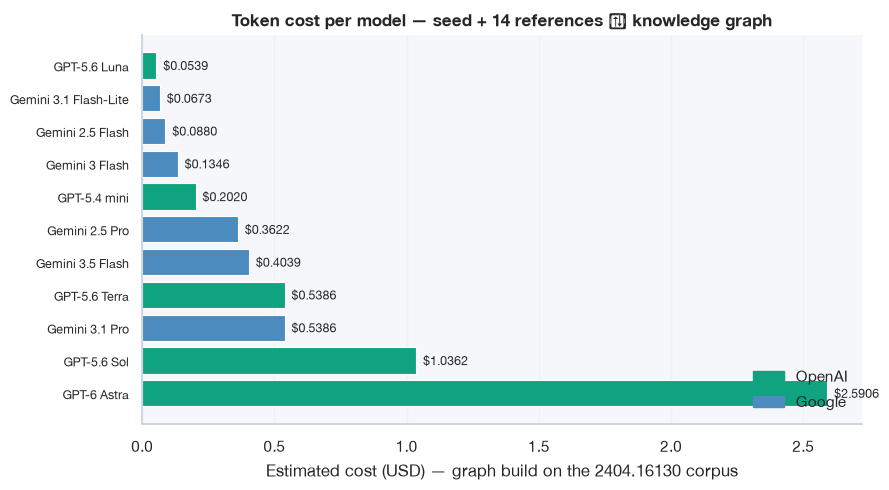

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="whitegrid", rc={
    "figure.facecolor": "white",
    "axes.facecolor": "#f5f7fa",
    "axes.edgecolor": "#c9d1d9",
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.color": "#e4e9f0",
    "font.sans-serif": ["Helvetica Neue", "Arial", "DejaVu Sans"],
    "font.size": 10,
    "axes.titleweight": "semibold",
})

order = df_cost["model"].tolist()
vals = df_cost["total_usd (GPT tokenizer)"].values
cols = ["#10a37f" if v == "OpenAI" else "#4b8bbe" for v in df_cost["vendor"]]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(range(len(order)), vals, color=cols, edgecolor="white", linewidth=0.8)
ax.set_yticks(range(len(order)), order, fontsize=9)
ax.set_xlabel("Estimated cost (USD) \u2014 graph build on the 2404.16130 corpus")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.4)
for b, v in zip(bars, vals):
    ax.text(b.get_width() + max(vals) * 0.01, b.get_y() + b.get_height() / 2,
            f"${v:,.4f}", va="center", fontsize=9)
ax.legend(handles=[mpatches.Patch(color="#10a37f", label="OpenAI"),
                   mpatches.Patch(color="#4b8bbe", label="Google")], loc="lower right",
          frameon=False)
ax.set_title("Token cost per model \u2014 seed + 14 references \u2192 knowledge graph")
plt.tight_layout()
plt.show()


## 4 · Does the local xlarge make sense? TCO & concurrency crossover

The repo currently deploys a **single `t3.xlarge` EC2** (`eu-north-1`, 4 vCPU / 16 GiB,
**CPU-only**) that runs the whole stack locally: GLiNER-large on Torch + Qwen3:0.6b served by
Ollama (`docs/architecture/deployment.md`). This section asks when that fixed-cost box beats the
**pay-per-call alternative**: a minimal orchestrator instance (`t3.micro`) that just shells out to
the OpenAI / Gemini APIs for the same graph.

The comparison has three moving parts:

| Dimension | Local xlarge (today) | Pay-per-call API |
| --- | --- | --- |
| Fixed compute (both 24/7) | `t3.xlarge` **~$126/mo** | `t3.micro` orchestrator **~$8/mo** |
| Marginal cost | ~$0 per analysis (Qwen3 sees only ≤1.5K-char contexts; GLiNER is NER, no LLM tokens) | Part A token prices: **$0.05 to $2.6 per analysis** |
| Throughput ceiling | CPU-bound: ~6 analyses/h (assumption, see below) | Rate-limited: RPM / TPM / RPD per model |
| Elasticity | Fixed 4 vCPU; scale out = another xlarge | Scales to rate limits; tiers unlock more |

**Assumptions (snapshot 2026-09-04, `eu-north-1`):**

- **Job latency `JOB_MINUTES = 10`** — there is *no timing instrumentation in this repo*, so this is
  a conservative estimate for one analysis on the xlarge (ref fetch ≈ 1–2 min; 15 sequential Qwen
  calls on Qwen3 0.6b ≈ 4–5 min; GLiNER-large extraction ≈ 2–3 min; merging/detection ≈ 1 min).
  **Measure it and adjust the constant** — every throughput line below scales linearly with it.
- **`CONCURRENT_LOCAL = 1`** — inside a job the LLM phases are sequential (Qwen loops over refs one
  call at a time; GLiNER loops over docs), and GLiNER/torch saturate all 4 vCPUs while running, so
  a second concurrent job would contend. This is the parallelizability question — see § 4.4.
- One analysis = 1 API call per document (15 calls) + 1 graph-output call (16 calls), same layout as
  Part A, using the GPT (`o200k`) token counts (`TOKENS_PER_JOB ≈ 218K`).
- Rate limits are **per project/org**, rolling 60 s (and RPD rolling 24 h on Gemini free). These are
  the *paid Tier-1* and *free* defaults reported by Google's docs and OpenAI/third-party trackers
  (Astra 500 RPM / 500K TPM @ Tier 1; GPT-5.6 family ≈ 500 RPM / 30K TPM @ Tier 1; Gemini Flash-Lite
  free 15 RPM / 250K TPM / 1,000 RPD; Flash-Lite paid ≈ 4K RPM / 4M TPM). Live values live in the
  provider consoles — edit `RATE_LIMITS` below.

**Both sides run 24/7**; waking the xlarge down ~8h/day (~$42/mo) is only a sensitivity lever.


In [9]:
# ---- §4 .1  knobs: infra & local behaviour -------------------------------
T3_XLARGE_H    = 0.1728     # on-demand $/hr, t3.xlarge, eu-north-1 (4 vCPU / 16 GiB, CPU-only)
T3_MICRO_H     = 0.0108     # on-demand $/hr, t3.micro (orchestrator of the API path)
LOCAL_HOURS_DAY = 24        # wake/stop demo: set 8
ORCH_HOURS_DAY  = 24
HOURS_MONTH     = 30.41 * 24

JOB_MINUTES      = 10.0     # wall-clock per analysis on the xlarge (ASSUMPTION — measure!)
CONCURRENT_LOCAL = 1        # sequential phases inside a job; ~1 job saturates the 4 vCPU box

# ---- §4 .1  knobs: workload shape (from Part A, GPT o200k basis) ----------
in_tok         = df_input["gpt_o200k_tokens"].sum()       # 207,866
out_tok        = df_output.loc[0, "gpt_o200k_tokens"]     # 10,239 (graph JSON row)
TOKENS_PER_JOB = in_tok + out_tok
N_CALLS        = len(docs) + 1                            # 15 input calls + 1 graph-output call

# ---- §4 .1  knobs: API rate limits (Tier-1 paid / free; snapshot 2026-09-04) -----
# (rpm, tpm, rpd) — rpd None means no published daily cap.
RATE_LIMITS = {
    "GPT-6 Astra":       {"tier1": (500, 500_000, None),      "free": None},
    "GPT-5.6 Luna":      {"tier1": (500, 30_000, None),       "free": None},
    "GPT-5.6 Sol":       {"tier1": (500, 30_000, None),       "free": None},
    "GPT-5.4 mini":      {"tier1": (500, 30_000, None),       "free": None},
    "Gemini 3.1 Flash-Lite": {"tier1": (4000, 4_000_000, None), "free": (15, 250_000, 1_000)},
    "Gemini 2.5 Flash":  {"tier1": (1000, 1_000_000, None),   "free": (10, 250_000, 1_500)},
    "Gemini 2.5 Pro":    {"tier1": (150, 2_000_000, None),    "free": (5, 150_000, 50)},
    "Gemini 3.1 Pro":    {"tier1": (150, 2_000_000, None),    "free": None},
}

VENDOR = {m: PRICES[m]["vendor"] for m in RATE_LIMITS}

print(f"Workload: {N_CALLS} calls / ~{TOKENS_PER_JOB:,} tokens per analysis job")
print(f"Local fixed cost : always-on ~${T3_XLARGE_H*LOCAL_HOURS_DAY*30.41:.0f}/mo "
      f"(wake/stop ~8h: ~${T3_XLARGE_H*8*30.41:.0f}/mo)")
print(f"Orchestrator cost: ~${T3_MICRO_H*ORCH_HOURS_DAY*30.41:.1f}/mo")
print(f"Local capacity   : {CONCURRENT_LOCAL*60/JOB_MINUTES:.0f} jobs/h "
      f"({CONCURRENT_LOCAL*60/JOB_MINUTES*24:.0f}/day at {LOCAL_HOURS_DAY}h/day)")


Workload: 16 calls / ~218,105 tokens per analysis job
Local fixed cost : always-on ~$126/mo (wake/stop ~8h: ~$42/mo)
Orchestrator cost: ~$7.9/mo
Local capacity   : 6 jobs/h (144/day at 24h/day)


In [10]:
# ---- §4 .2  throughput ceiling: rate limits vs local CPU ------------------
rows = []
for model, tiers in RATE_LIMITS.items():
    for tier, lim in tiers.items():
        if lim is None:
            rows.append({
                "model": model, "vendor": VENDOR[model], "tier": tier,
                "rpm": None, "tpm": None, "rpd": None,
                "jobs/hr": float("nan"), "jobs/day": float("nan"),
            })
            continue
        rpm, tpm, rpd = lim
        jph_rpm = rpm * 60 / N_CALLS
        jph_tpm = tpm / TOKENS_PER_JOB * 60
        jph = min(jph_rpm, jph_tpm)
        jpd = min(jph * 24, (rpd / N_CALLS) if rpd else float("inf"))
        rows.append({
            "model": model, "vendor": VENDOR[model], "tier": tier,
            "rpm": rpm, "tpm": tpm, "rpd": rpd,
            "jobs/hr": round(jph, 1), "jobs/day": round(jpd, 1),
        })

df_cap = pd.DataFrame(rows)
LOCAL_JPD = {"always-on": CONCURRENT_LOCAL * 60 / JOB_MINUTES * 24,
             "wake/stop": CONCURRENT_LOCAL * 60 / JOB_MINUTES * 8}
print("Local xlarge ceiling: always-on ~%.0f jobs/day | wake/stop(8h) ~%.0f jobs/day"
      % (LOCAL_JPD["always-on"], LOCAL_JPD["wake/stop"]))
display(df_cap[["model", "vendor", "tier", "rpm", "tpm", "rpd", "jobs/hr", "jobs/day"]]
        .style.format({"jobs/hr": "{:.0f}", "jobs/day": "{:.0f}"}))


Local xlarge ceiling: always-on ~144 jobs/day | wake/stop(8h) ~48 jobs/day


,model,vendor,tier,rpm,tpm,rpd,jobs/hr,jobs/day
0,GPT-6 Astra,OpenAI,tier1,500.000000,500000.000000,nan,138,3301
1,GPT-6 Astra,OpenAI,free,nan,nan,nan,nan,nan
2,GPT-5.6 Luna,OpenAI,tier1,500.000000,30000.000000,nan,8,198
3,GPT-5.6 Luna,OpenAI,free,nan,nan,nan,nan,nan
4,GPT-5.6 Sol,OpenAI,tier1,500.000000,30000.000000,nan,8,198
5,GPT-5.6 Sol,OpenAI,free,nan,nan,nan,nan,nan
6,GPT-5.4 mini,OpenAI,tier1,500.000000,30000.000000,nan,8,198
7,GPT-5.4 mini,OpenAI,free,nan,nan,nan,nan,nan
8,Gemini 3.1 Flash-Lite,Google,tier1,4000.000000,4000000.000000,nan,1100,26409
9,Gemini 3.1 Flash-Lite,Google,free,15.000000,250000.000000,1000.000000,56,62


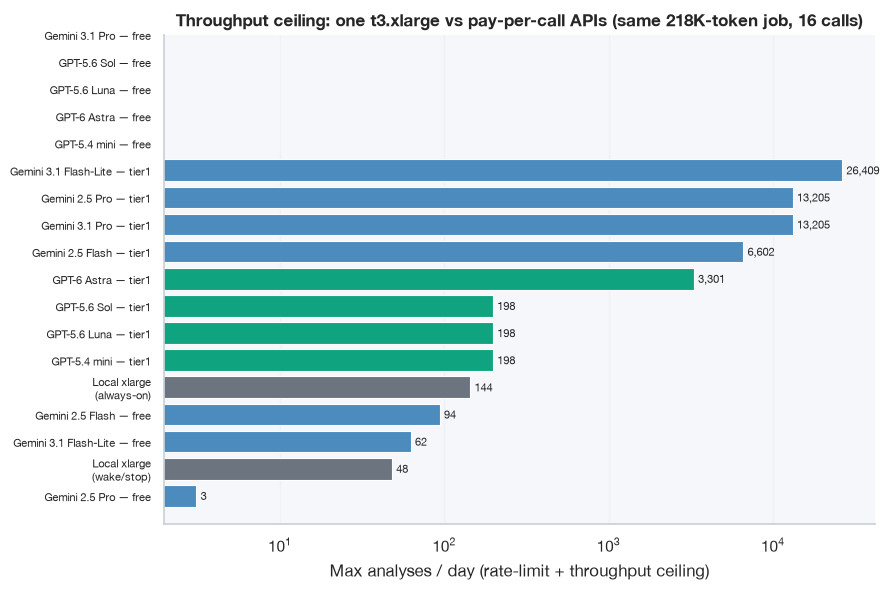

In [11]:
# ---- §4 .2  chart: sustainable analyses/day, local vs API ------------------
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid", rc={
    "figure.facecolor": "white",
    "axes.facecolor": "#f5f7fa",
    "axes.edgecolor": "#c9d1d9",
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.color": "#e4e9f0",
    "font.sans-serif": ["Helvetica Neue", "Arial", "DejaVu Sans"],
    "font.size": 10,
    "axes.titleweight": "semibold",
})

labels, vals, cols = [], [], []
for loc_label, jpd in LOCAL_JPD.items():
    labels.append("Local xlarge\n(" + loc_label + ")")
    vals.append(jpd)
    cols.append("#6c7480")

for tier in ("tier1", "free"):
    sub = df_cap[df_cap["tier"] == tier].sort_values("jobs/day", ascending=False)
    for _, r in sub.iterrows():
        labels.append(f"{r['model']} \u2014 {tier}")
        vals.append(r["jobs/day"])
        cols.append("#10a37f" if r["vendor"] == "OpenAI" else "#4b8bbe")

order = np.argsort(vals)
labels = [labels[k] for k in order]
vals = [vals[k] for k in order]
cols = [cols[k] for k in order]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(range(len(labels)), vals, color=cols, edgecolor="white", linewidth=0.8)
ax.set_yticks(range(len(labels)), labels, fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("Max analyses / day (rate-limit + throughput ceiling)")
ax.grid(axis="x", alpha=0.4)
for b, v in zip(bars, vals):
    ax.text(b.get_width() * 1.06, b.get_y() + b.get_height() / 2,
            f"{v:,.0f}", va="center", fontsize=8)
ax.set_title("Throughput ceiling: one t3.xlarge vs pay-per-call APIs "
             "(same 218K-token job, 16 calls)")
plt.tight_layout()
plt.show()


In [12]:
# ---- §4 .3  cost crossover: concurrent users that make the xlarge viable ---
C_local_alw = T3_XLARGE_H * LOCAL_HOURS_DAY * 30.41
C_local_8h  = T3_XLARGE_H * 8 * 30.41
C_orch      = T3_MICRO_H * ORCH_HOURS_DAY * 30.41

c_job = {
    m: round((in_tok / 1e6) * PRICES[m]["input"] + (out_tok / 1e6) * PRICES[m]["output"], 4)
    for m in PRICES
}
V_star = {m: (C_local_alw - C_orch) / c for m, c in c_job.items()}   # jobs/mo breakeven (always-on)

print(f"Local always-on {C_local_alw:.0f}$/mo minus {C_orch:.0f}$/mo orchestrator "
      f"= pay-as-you-go budget of {C_local_alw-C_orch:.0f}$/mo")

rows = []
for m in c_job:
    rows.append({
        "model": m, "vendor": PRICES[m]["vendor"], "cost_per_job_usd": c_job[m],
        "jobs_mo_breakeven": round(V_star[m], 1),
        "users_@1_job_mo": round(V_star[m] / 1, 1),
        "users_@10_jobs_mo": round(V_star[m] / 10, 1),
    })
df_be = pd.DataFrame(rows).sort_values("cost_per_job_usd")
display(df_be.style.format({
    "cost_per_job_usd": "${:.4f}",
    "jobs_mo_breakeven": "{:,.0f}",
    "users_@1_job_mo": "{:,.0f}",
    "users_@10_jobs_mo": "{:,.0f}",
}))
print("Reading: above 'jobs_mo_breakeven' the always-on xlarge is the cheaper writer of the same graph;")
print("at that point divide by the per-user recurrence to get the concurrent-user threshold.")

Local always-on 126$/mo minus 8$/mo orchestrator = pay-as-you-go budget of 118$/mo


,model,vendor,cost_per_job_usd,jobs_mo_breakeven,users_@1_job_mo,users_@10_jobs_mo
3,GPT-5.6 Luna,OpenAI,$0.0539,"2,194","2,194",219
10,Gemini 3.1 Flash-Lite,Google,$0.0673,"1,757","1,757",176
9,Gemini 2.5 Flash,Google,$0.0880,"1,344","1,344",134
7,Gemini 3 Flash,Google,$0.1346,878,878,88
4,GPT-5.4 mini,OpenAI,$0.2020,585,585,58
8,Gemini 2.5 Pro,Google,$0.3622,326,326,33
6,Gemini 3.5 Flash,Google,$0.4039,293,293,29
2,GPT-5.6 Terra,OpenAI,$0.5386,220,220,22
5,Gemini 3.1 Pro,Google,$0.5386,220,220,22
1,GPT-5.6 Sol,OpenAI,$1.0362,114,114,11


Reading: above 'jobs_mo_breakeven' the always-on xlarge is the cheaper writer of the same graph;
at that point divide by the per-user recurrence to get the concurrent-user threshold.


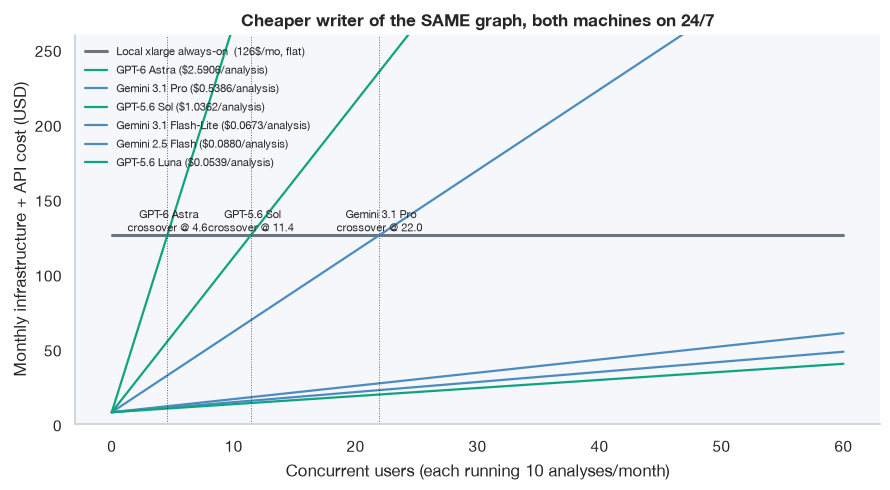

In [13]:
# ---- §4 .3  chart: monthly cost vs concurrent users (R = 10 analyses/user/mo) ---
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid", rc={
    "figure.facecolor": "white",
    "axes.facecolor": "#f5f7fa",
    "axes.edgecolor": "#c9d1d9",
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.color": "#e4e9f0",
    "font.sans-serif": ["Helvetica Neue", "Arial", "DejaVu Sans"],
    "font.size": 10,
    "axes.titleweight": "semibold",
})

R_PER_USER = 10
U = np.arange(0, 61, 1)
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(U, np.full_like(U, C_local_alw), color="#6c7480", lw=2.2, ls="-",
        label=f"Local xlarge always-on  ({C_local_alw:.0f}$/mo, flat)")

for m, col in [("GPT-6 Astra", "#10a37f"), ("Gemini 3.1 Pro", "#4b8bbe"),
               ("GPT-5.6 Sol", "#10a37f"), ("Gemini 3.1 Flash-Lite", "#4b8bbe"),
               ("Gemini 2.5 Flash", "#4b8bbe"), ("GPT-5.6 Luna", "#10a37f")]:
    ax.plot(U, C_orch + R_PER_USER * U * c_job[m], color=col, lw=1.6,
            label=f"{m} (${c_job[m]:.4f}/analysis)")

for m in ["GPT-6 Astra", "Gemini 3.1 Pro", "GPT-5.6 Sol"]:
    ux = V_star[m] / R_PER_USER
    if ux <= U.max():
        ax.axvline(ux, color="black", lw=0.7, ls=":", alpha=0.6)
        ax.text(ux, C_local_alw * 1.02, f" {m}\ncrossover @ {ux:.1f}", fontsize=8, ha="center")

ax.set_xlabel("Concurrent users (each running 10 analyses/month)")
ax.set_ylabel("Monthly infrastructure + API cost (USD)")
ax.set_ylim(0, 260)
ax.legend(fontsize=8, loc="upper left", frameon=False)
ax.set_title("Cheaper writer of the SAME graph, both machines on 24/7")
plt.tight_layout()
plt.show()


### § 4.4 · The three questions, answered

**1 · How parallelizable is the current solution (per job, and across recurrence)?**
The pipeline is *embarrassingly parallel at the document level but runs sequentially*. Fetching the
references already fans out to 8 threads, but the two LLM-heavy phases are serial loops: Qwen
analyzes each reference one call at a time (≈15 calls), then GLiNER extracts each document one at a
time — while GLiNER/torch uses all 4 vCPUs. So one analysis is effectively **1 job on a 4-core box**,
and `t3.xlarge` is chosen *for memory* (16 GiB; `t3.large` OOMs), not for CPU headroom. Recurrence
(repeated, independent analyses) is trivially parallelizable *across* jobs, but each concurrent job
contends for the same cores; realistic concurrency is ~1–2, and the safe scale-out is another
`t3.xlarge` — a fixed-cost step, not a smooth curve. The headroom unlocked by parallelizing the doc
loop is up to ~4×, at the price of predictable Ollama/GLiNER concurrency.

**2 · When does the local `xlarge` become viable?**
Breakeven is **~46 analyses/month with a frontier model (GPT-6 Astra), ~220 with Gemini 3.1 Pro /
GPT-5.6 Terra-class, and ~1,750 with the cheapest models (Flash-Lite, Luna)** — those are the always-on
`xlarge` ceilings. In **concurrent-user** terms with a typical *10 analyses/user/month* recurrence:
**~4–5 users** on Astra-class models, ~20 users on Pro/Terra class, ~175 users on Flash-Lite/Luna
class. All thresholds assume **both machines on 24/7**; waking the xlarge down (~8h/day ≈ $42/mo)
is a separate lever that shifts every crossover by ~3×, at the cost of local capacity
(~48 jobs/day). Below those volumes the API path on a tiny orchestrator is cheaper *everywhere*
(marginal ≈ cents per graph), and a free Gemini key alone covers up to ~62 analyses/day.

**3 · Do rate limits matter?**
Yes — for the pay-per-call path they bind before money does. GPT-5.6-family Tier-1 is capped at
**≈8 analyses/h** (30K TPM), i.e. ~200/day — *below* a busy always-on xlarge. The Gemini **free**
tier caps Flash-Lite at **1,000 requests/day ≈ 62 analyses/day**. Only GPT-6 Astra Tier-1 and paid
Gemini Flash-Lite/Pro clear the xlarge's sustained ceiling (3.3K–26K/day), and they are exactly the
models whose per-job price made the local box attractive. So: rate limits compress the API path's
advantage at the *cheap* end and reinforce the local box at the *frontier* end.

### Bottom line
The local `t3.xlarge` is **over-provisioned for a demo/small workload** — an API-backed tiny instance
is simpler and cheaper up to a few hundred analyses/month on cheap models. The box earns its $126/mo
when (a) the workload is sustained and uses Pro/Astra-class extraction (≥ ~50–220 analyses/mo),
(b) documents must stay **in-house** (GLiNER + Qwen3 never leave the VPC), or (c) cost-per-analysis
must be flat regardless of volume. The cheapest free-Gemini path is a free prototype tier worth
testing against — 62 analyses/day for $0 infra.


## 5 · Conclusions: when does OUR current design make sense?

This notebook doubles as a self-audit of the repo's own production choice — a single always-on
`t3.xlarge` (GLiNER + Qwen3/Ollama on CPU, 16 GiB) versus a minimal `t3.micro` that simply calls
paid APIs. The honest, self-critical reading:

1. **Our current local-only deployment is not viable at the usage we actually have.** With both
   machines on 24/7, the xlarge's extra ~$118/mo of fixed cost buys nothing until the API token bill
   crosses it — i.e. until **~46 analyses/mo on frontier models (GPT-6 Astra) or ~1,750 analyses/mo
   on cheap models (Flash-Lite/Luna)**. In concurrent-user terms (10 analyses/user/mo) that is
   **~5 to ~175 users** depending on model class. Below that band a `t3.micro` + tokens is a cheaper
   machine and a simpler system (runbook: [deployment.md](../../docs/architecture/deployment.md),
   §6).
2. **The xlarge was sized from a memory constraint, not from load.** `t3.large` OOMs on GLiNER's
   3.5 GB model + torch, so we stepped up to 16 GiB; the extra 4 vCPU are mostly idle because both
   expensive loops (Qwen → references, GLiNER → documents) run sequentially. We bought headroom we
   do not use.
3. **We assumed the hardest number.** `JOB_MINUTES = 10` is unmeasured — there is no timing
   instrumentation anywhere in the repo. Every crossover above scales linearly with it; a production
   decision needs one afternoon of real timings on the box.
4. **The API path was deliberately skipped, and by design it is the cheaper one.** It removes
   ~$120/mo of fixed cost, deletes Ollama + 16 GiB from the ops surface, and is the only path that
   can ride Gemini's free tier (~62 analyses/day at $0). The reasons to keep local inference — data
   never leaves the VPC, flat cost under sustained volume, frontier quality at ~46/mo breakeven — are
   *product* reasons, not *scale* reasons.
5. **Rate limits punish the API path exactly where the box becomes attractive.** GPT-5.6 Tier-1 caps
   at ~200 analyses/day; free Gemini at ~62/day. The sustained, privacy-sensitive, cheap-model
   workload is the one region where the flat xlarge genuinely wins — not small recurring demos.

**What we would change, in order of leverage:** instrument the pipeline (per-phase timings) → run
the API tier from a `t3.micro` while volume is low → keep the local inference stack as an opt-in
"private/offline" profile → scale to a GPU box only once volume crosses the breakeven band of the
model class actually used.

Companion doc: [deployment.md](../../docs/architecture/deployment.md) — the runbook this experiment
prices against.


## Takeaways

1. **Input dominates the bill.** The 15 documents total ~950K chars, i.e. roughly
   208–221K input tokens, versus only ~10–16K tokens of graph output. On a frontier reasoning
   model (GPT-6 Astra) a one-shot build costs **~$2.6**, while on GPT-5.6 Luna the same graph
   costs **~$0.05**.
2. **Output is nearly free.** The exported graph (96 nodes / 58 edges) is only ~10,200 tokens
   (GPT tokenizer), well under 1% of the bill. Once the corpus is in context, emitting the
   graph costs almost nothing.
3. **Model choice spans ~48× in cost** for the same graph — from GPT-5.6 Luna ($0.054) to
   GPT-6 Astra ($2.59); GPT-6 vs Gemini 3.1 Flash-Lite is ~38×. Per graph everything is small;
   the economics only bite at scale (many papers, or chunked/iterative GraphRAG indexing).
4. **Tokenizers disagree slightly.** GPT's `o200k` and Gemini's Gemma-3 SentencePiece give
   nearby but not identical counts for the same text (207,866 vs 220,628 input tokens here),
   which is why both `total_usd` columns are shown.
5. **Caveats.** A real run adds system prompts, framing and retries; crossing the 200K-context
   tier (Gemini Pro) or the 272K lane (GPT-6) doubles input rates; Batch halves most prices;
   and prompt caching can cut the input side dramatically on re-runs.

### Reproduce / extend

- `Kernel → Restart & Run All` (no API keys needed).
- Change `SEED_ID` / `MAX_REFS` / `TRUNCATE_CHARS` to try other corpora.
- Refresh `PRICES` to today's rates.
- To go from simulation to reality, call the provider (OpenAI / `google-genai`) once per
  document and read back `usage` — the counts above already use the exact tokenizers.

### Part B in 10 seconds

- **Current box is overkill for a demo**: below ~1,750 analyses/mo on cheap models (Flash-Lite/
  Luna) the API + a `t3.micro` is cheaper; free Gemini covers ~62 analyses/day for $0.
- **By concurrency (at 10 analyses/user/mo)**: local `xlarge` turns viable at ~4–5 users with
  GPT-6 Astra-class pricing, ~20 users with Pro/Terra-class, ~175 users with Flash-Lite/Luna-class.
- **Rate limits bind before money**: GPT-5.6 Tier-1 ≈ 8 analyses/h; Gemini free ≈ 62/day; only paid
  Gemini Flash-Lite and Astra Tier-1 clear the xlarge's sustained ceiling.
- **Parallelism**: doc-level loop is embarrassingly parallel but runs sequentially (~1 job/4 vCPU);
  recurrence parallelizes across jobs, capped at ~1–2 concurrent; scale-out is another xlarge.
- **Privacy / flat-cost / sustained frontier quality** (≥ ~220 analyses/mo of Pro/Astra work) shells
  out in favor of keeping the box. Measure `JOB_MINUTES` on the deployed xlarge to firm these ups.
6. **Yes, we are criticising our own deployment.** §5 argues the local-only `t3.xlarge` only
   earns its ~$118/mo premium once volume reaches ~46 (frontier) to ~1,750 (cheap) analyses/mo —
   i.e. ~5–175 concurrent users at 10 analyses/user/mo.
